<a href="https://colab.research.google.com/github/pulseq/ISMRM-Virtual-Meeting--February-24-26-2026/blob/main/tutorials/day1_basicPulseqTutorial/Jupyter_Notebooks/s02_fid2gre1d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# from FID to 1D GRE
**Exercise**:   
This exercise starts from the FID. Now extend the FID to 1D GRE by inserting the trapezoid readout gradient and its pre-phaser to the sequence.

In [1]:
#@title GRE 1D in a pixel phantom - environment setup
!pip show pypulseq || pip install pypulseq==1.4.2
import pypulseq as pp

# for MRzero simulation
!pip show MRzeroCore || pip install MRzeroCore
!wget https://github.com/MRsources/MRzero-Core/raw/main/documentation/playground_mr0/util.py &> /dev/null
#!wget https://github.com/MRsources/MRzero-Core/raw/main/documentation/playground_mr0/numerical_brain_cropped.mat &> /dev/null
import MRzeroCore as mr0

import numpy as np
from matplotlib import pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.0/278.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.1/254.1 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.7/108.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.3/377.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.0/475.0 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 20.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Timing check passed successfully


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


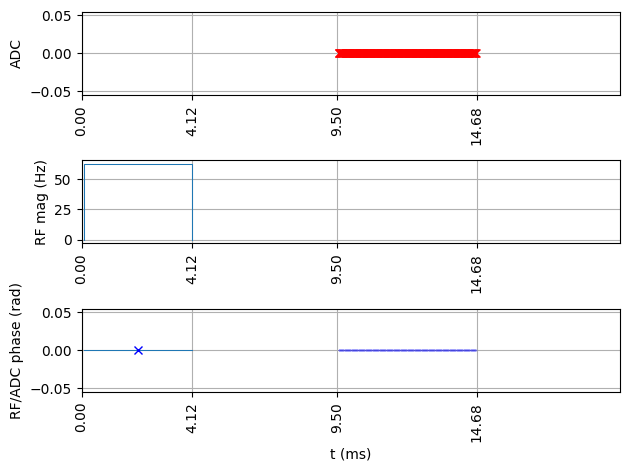

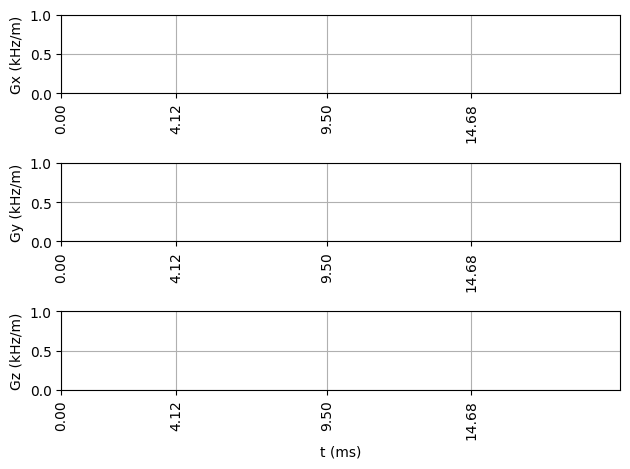

'eaec0f335805721ba25c5896f44c0b6f'

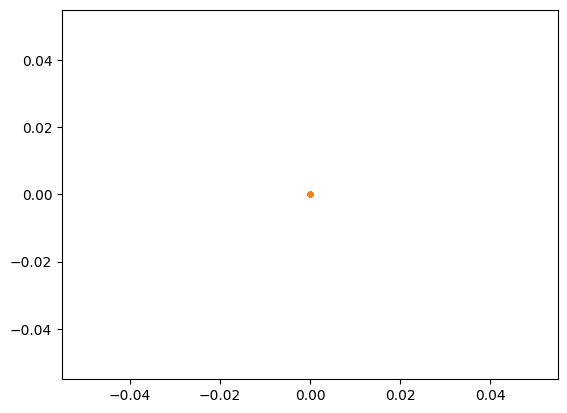

In [2]:
#@title 1D GRE in a pixel phantom - sequence

# Define number of ADC samples
fov = 256e-3
Nread = 256
TE = 10e-3 # echo time
TR = 10 # repetition time

# Setup scanner limits
sys = pp.Opts(
    max_grad=28, grad_unit='mT/m', max_slew=150, slew_unit='T/m/s',
    rf_ringdown_time=20e-6, rf_dead_time=100e-6,
    adc_dead_time=20e-6, grad_raster_time=10e-6)

# Setup sequence object
seq = pp.Sequence(sys)

# Define RF event, 90-deg hard pulse for excitation
rf_ex = pp.make_block_pulse(flip_angle=90*np.pi/180, duration=4e-3, phase_offset=0*np.pi/180, delay=10e-6, system=sys)

# Define ADC event
adc = pp.make_adc(num_samples=Nread, duration=5.12e-3, phase_offset=0*np.pi/180, delay=10e-6, system=sys)

# Define readout gradients
deltak = 1/fov
gx = pp.make_trapezoid(channel='x', flat_area=Nread*deltak, flat_time=adc.dwell*adc.num_samples, system=sys) # readout gradient
adc.delay = gx.rise_time
gx_pre = pp.make_trapezoid(channel='x', area=-gx.area/2, duration=4e-3, system=sys) # readout pre-phaser

# Calculate timing
delayTE = TE - rf_ex.shape_dur/2 - rf_ex.ringdown_time - pp.calc_duration(gx)/2
delayTR = TR - pp.calc_duration(rf_ex) - delayTE - pp.calc_duration(gx)

# ======
# CONSTRUCT SEQUENCE
# ======
seq.add_block(rf_ex)
seq.add_block(pp.make_delay(delayTE))
seq.add_block(adc)
seq.add_block(pp.make_delay(delayTR))

# Check timing
(ok, error_report) = seq.check_timing()  # Check whether the timing of the sequence is correct
if ok:
    print("Timing check passed successfully")
else:
    print("Timing check failed. Error listing follows:")
    [print(e) for e in error_report]

# Plot sequence diagram
time_range = [0, 0.02]
seq.plot(time_range=time_range, time_disp='ms', show_blocks=True)

# Plot k-space trajectory
k_traj_adc, k_traj, t_excitation, t_refocusing, t_adc = seq.calculate_kspace()

plt.figure()
plt.plot(k_traj[0],k_traj[1])
plt.plot(k_traj_adc[0],k_traj_adc[1],'.')

# Prepare the sequence output for the scanner
seq.set_definition('Name', 'fid')
seq.write('s02_fid2gre1d.seq')

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


CustomVoxelPhantom
Voxel shape: box
Voxel size: tensor([0.1000, 0.1000, 0.1000])


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


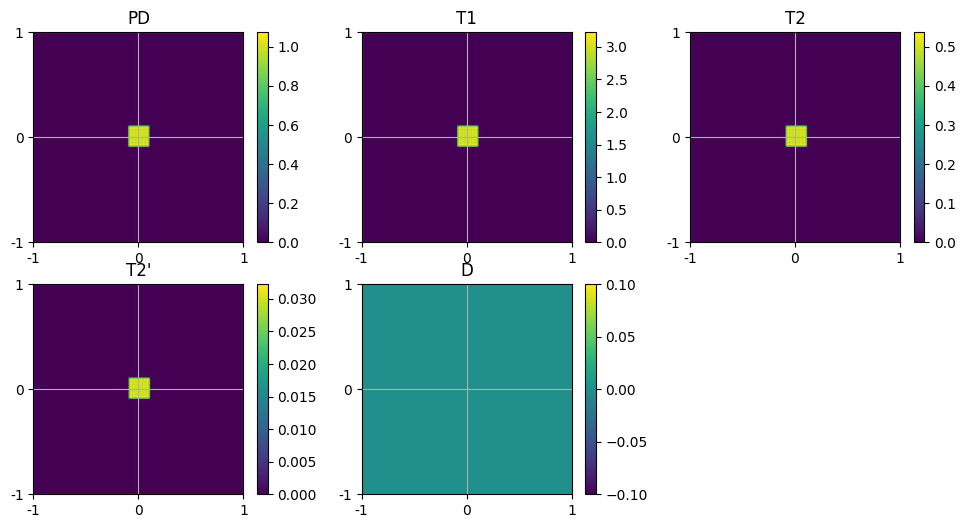

Calculating repetition 1 / 1 - done


In [3]:
#@title 1D GRE in a pixel phantom - simulation
# %% SETUP SPIN SYSTEM/object on which we can run the MR sequence .seq from above
# set phantom manually to a pixel phantom. Coordinate system is [-0.5, 0.5]^3
dB0 = 0
obj_p = mr0.CustomVoxelPhantom(
        pos=[[0., 0., 0.]],
        PD=[1.0],
        T1=[3.0],
        T2=[0.5],
        T2dash=[30e-3],
        D=[0.0],
        B0=0,
        voxel_size=0.1,
        voxel_shape="box"
    )
# Manipulate loaded data
obj_p.B0+=dB0
obj_p.D*=0
obj_p.plot()
# Convert Phantom into simulation data
obj_p=obj_p.build()

# %% SIMULATE  the external.seq file and add acquired signal to ADC plot
# Read in the sequence
seq0 = mr0.Sequence.import_file("s02_fid2gre1d.seq")
# Simulate the sequence
graph=mr0.compute_graph(seq0, obj_p, 200, 1e-3)
signal=mr0.execute_graph(graph, seq0, obj_p)

/tmp/ipython-input-1706176005.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(time_axis, np.abs(signal), label='abs')


Text(0, 0.5, 'Amplitude')

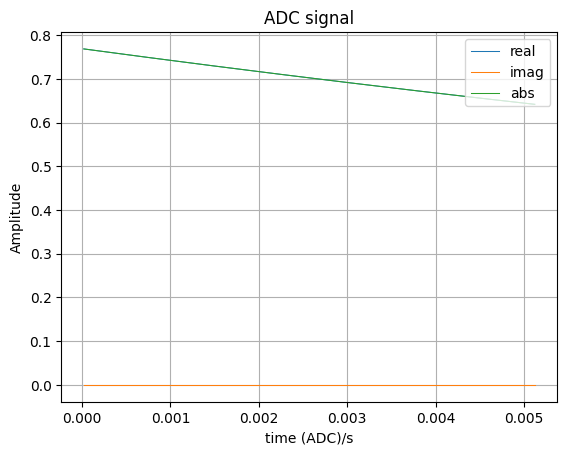

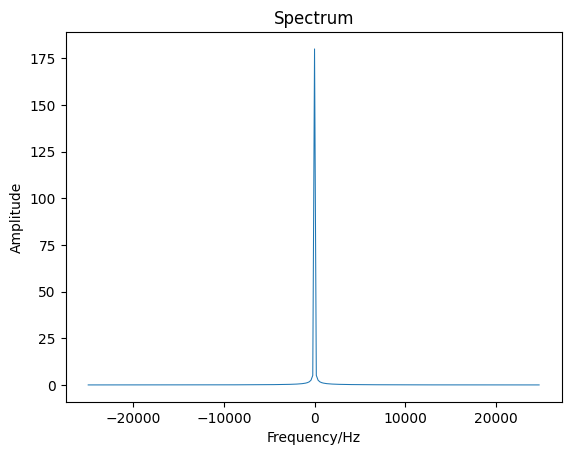

In [4]:
#@title 1D GRE in a pixel phantom - reconstruction
# 1D FFT
def fft_1d(x):
    return np.fft.fftshift(np.fft.fftn(np.fft.ifftshift(x)))

# detailed ADC plot for one repetition
plt.figure()
plt.title('ADC signal')
# time axis
time_axis=np.linspace(1, Nread, Nread)*adc.dwell ;
plt.plot(time_axis, np.real(signal), label='real')
plt.plot(time_axis, np.imag(signal), label='imag')
plt.plot(time_axis, np.abs(signal), label='abs')
plt.grid()
plt.legend(loc="upper right")
plt.xlabel('time (ADC)/s')
plt.ylabel('Amplitude')

# 1D FFT reconstruction
spectrum = fft_1d(signal)

# frequency axis
freq_axis = np.linspace(-Nread/2, Nread/2-1, Nread)/(adc.dwell*adc.num_samples)

plt.figure()
plt.title('Spectrum')
plt.plot(freq_axis, np.abs(spectrum))
plt.xlabel('Frequency/Hz')
plt.ylabel('Amplitude')